# 4. Asteroid Risk Prediction System - Final Model Evaluation

**Copyright © 2026 StellarMind - EarthGuard Asteroid Defense AI**  
**All Rights Reserved.**

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: StellarMind - EarthGuard Asteroid Defense AI  
**Goal**: Comprehensive evaluation, comparison, and final selection of best model

**License**: This code and its contents are proprietary to StellarMind.  
Unauthorized copying, distribution, or use of this material is prohibited without prior written permission.

**Version**: 1.0 | **Date**: April 2026

In [11]:
# 2. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import matthews_corrcoef, log_loss
import joblib
import warnings
warnings.filterwarnings('ignore')

In [12]:
# 3. Load test data and trained models
test_df = pd.read_csv('../data/processed/test.csv')
print("✓ Test data loaded")

rf_model = joblib.load('../models/random_forest.pkl')
dt_model = joblib.load('../models/decision_tree.pkl')
lr_model = joblib.load('../models/logistic_regression.pkl')
print("✓ All models loaded")

# Load results if exists
try:
    results_df = pd.read_csv('../reports/model_results.csv')
    print("✓ Previous results loaded")
except:
    results_df = None
    print("⚠️ No previous results found")

✓ Test data loaded
✓ All models loaded
✓ Previous results loaded


In [13]:
# 4. Prepare test data
target_col = 'is_potentially_hazardous_asteroid'
feature_cols = [col for col in test_df.columns if col != target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Test samples: {len(X_test)}")
print(f"Features: {len(feature_cols)}")
print(f"Hazardous ratio: {y_test.mean()*100:.2f}%")

Test samples: 5174
Features: 73
Hazardous ratio: 9.66%


In [14]:
# 5. Get all predictions
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print("✓ Predictions completed for all models")

✓ Predictions completed for all models


In [15]:
# 6. Comprehensive metrics calculation
def comprehensive_metrics(y_true, y_pred, y_proba, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Log Loss': log_loss(y_true, y_proba)
    }

metrics_list = []
metrics_list.append(comprehensive_metrics(y_test, rf_pred, rf_proba, 'Random Forest'))
metrics_list.append(comprehensive_metrics(y_test, dt_pred, dt_proba, 'Decision Tree'))
metrics_list.append(comprehensive_metrics(y_test, lr_pred, lr_proba, 'Logistic Regression'))

metrics_df = pd.DataFrame(metrics_list)
print("=== COMPREHENSIVE METRICS ===")
print(metrics_df.round(4))

=== COMPREHENSIVE METRICS ===
                 Model  Accuracy  Precision  Recall  F1-Score     MCC  \
0        Random Forest    0.9981     0.9900   0.990    0.9900  0.9889   
1        Decision Tree    0.9977     0.9880   0.988    0.9880  0.9867   
2  Logistic Regression    0.9453     0.6441   0.970    0.7741  0.7647   

   Log Loss  
0    0.0565  
1    0.0836  
2    0.1315  


In [16]:
# 7. Find and display best model for each metric
print("=== BEST MODEL BY EACH METRIC ===")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']:
    best_idx = metrics_df[metric].idxmax()
    best_model = metrics_df.loc[best_idx, 'Model']
    best_value = metrics_df.loc[best_idx, metric]
    print(f"{metric:12s}: {best_model:18s} ({best_value:.4f})")

# Overall best model (by F1-Score)
best_model = metrics_df.loc[metrics_df['F1-Score'].idxmax(), 'Model']
best_f1 = metrics_df['F1-Score'].max()
print(f"\n🏆 OVERALL BEST MODEL: {best_model} (F1-Score: {best_f1:.4f})")

=== BEST MODEL BY EACH METRIC ===
Accuracy    : Random Forest      (0.9981)
Precision   : Random Forest      (0.9900)
Recall      : Random Forest      (0.9900)
F1-Score    : Random Forest      (0.9900)
MCC         : Random Forest      (0.9889)

🏆 OVERALL BEST MODEL: Random Forest (F1-Score: 0.9900)


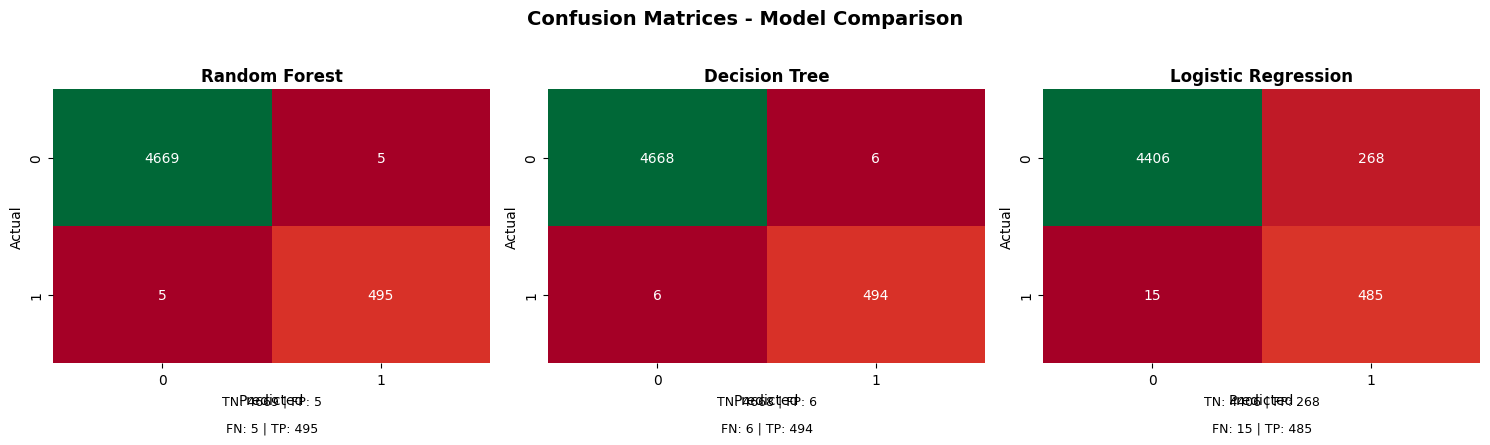

In [17]:
# 8. Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models_conf = [('Random Forest', rf_pred), ('Decision Tree', dt_pred), ('Logistic Regression', lr_pred)]

for idx, (name, pred) in enumerate(models_conf):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='RdYlGn', cbar=False)
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    
    # Add annotations
    axes[idx].text(0.5, -0.15, f'TN: {cm[0,0]} | FP: {cm[0,1]}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=9)
    axes[idx].text(0.5, -0.25, f'FN: {cm[1,0]} | TP: {cm[1,1]}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

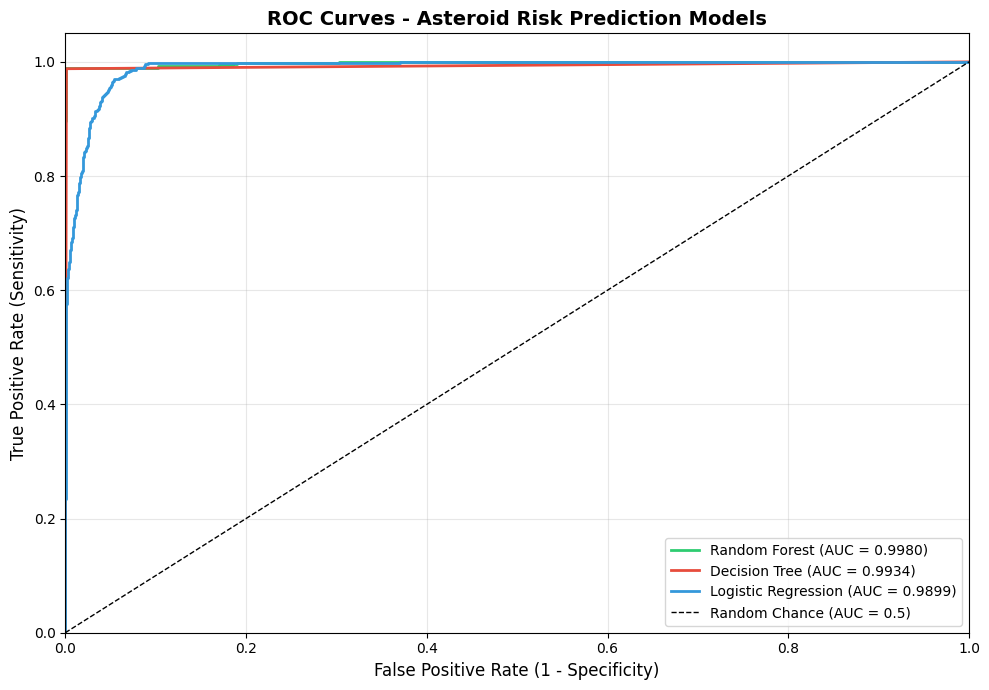

In [18]:
# 9. ROC Curves comparison
plt.figure(figsize=(10, 7))

models_roc = [('Random Forest', rf_proba, '#2ecc71'), 
              ('Decision Tree', dt_proba, '#e74c3c'), 
              ('Logistic Regression', lr_proba, '#3498db')]

for name, proba, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves - Asteroid Risk Prediction Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

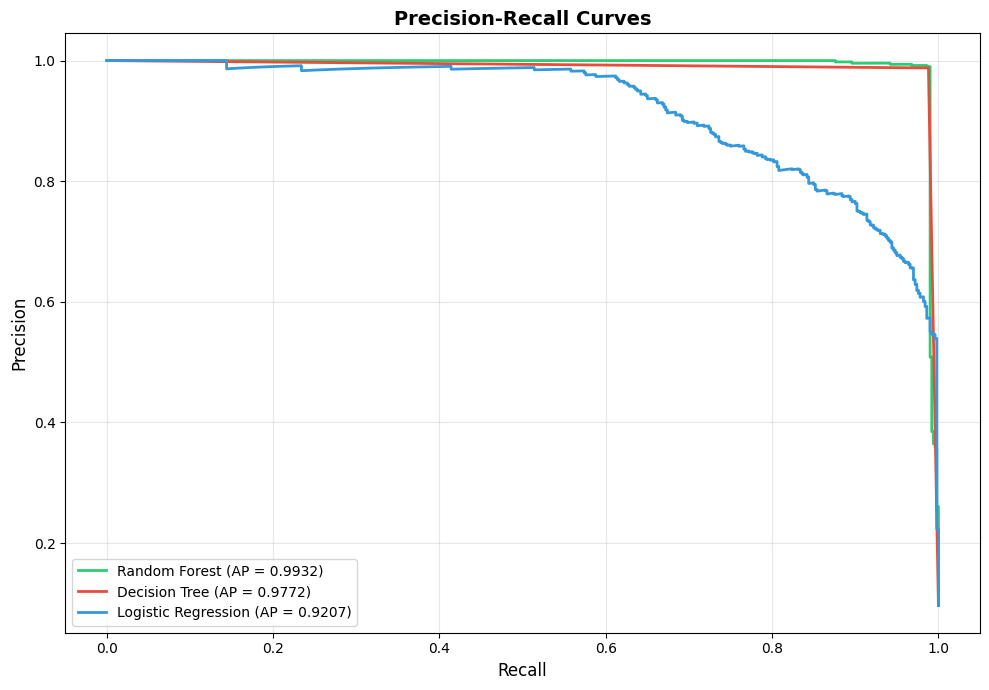

In [19]:
# 10. Precision-Recall Curve (important for imbalanced data)
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, proba, color in models_roc:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap_score = average_precision_score(y_test, proba)
    plt.plot(recall, precision, color=color, lw=2, label=f'{name} (AP = {ap_score:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

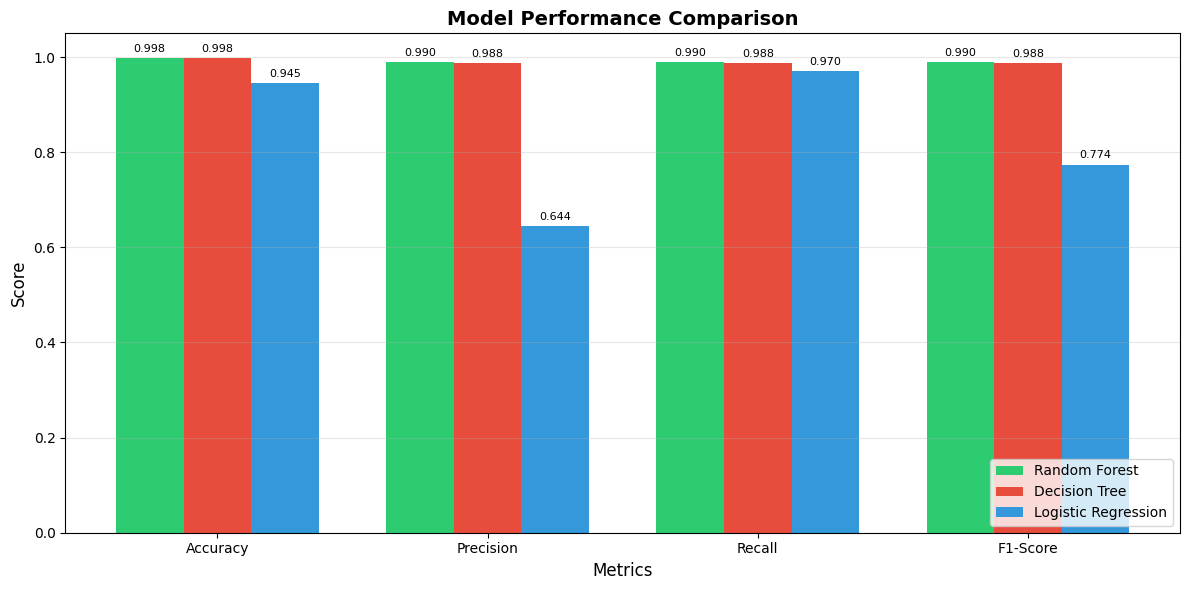

In [20]:
# 11. Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

rf_values = [metrics_df.loc[0, m] for m in metrics_to_plot]
dt_values = [metrics_df.loc[1, m] for m in metrics_to_plot]
lr_values = [metrics_df.loc[2, m] for m in metrics_to_plot]

bars1 = ax.bar(x - width, rf_values, width, label='Random Forest', color='#2ecc71')
bars2 = ax.bar(x, dt_values, width, label='Decision Tree', color='#e74c3c')
bars3 = ax.bar(x + width, lr_values, width, label='Logistic Regression', color='#3498db')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# 12. Error analysis - where models disagree
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'RF_Pred': rf_pred,
    'DT_Pred': dt_pred,
    'LR_Pred': lr_pred,
    'RF_Proba': rf_proba,
    'DT_Proba': dt_proba,
    'LR_Proba': lr_proba
})

# Find cases where models disagree
predictions_df['Agreement'] = (predictions_df['RF_Pred'] == predictions_df['DT_Pred']) & \
                               (predictions_df['DT_Pred'] == predictions_df['LR_Pred'])

disagreement_cases = predictions_df[~predictions_df['Agreement']]
agreement_cases = predictions_df[predictions_df['Agreement']]

print("=== ERROR ANALYSIS ===")
print(f"Total test samples: {len(predictions_df)}")
print(f"All models agree: {len(agreement_cases)} ({len(agreement_cases)/len(predictions_df)*100:.1f}%)")
print(f"Models disagree: {len(disagreement_cases)} ({len(disagreement_cases)/len(predictions_df)*100:.1f}%)")

if len(disagreement_cases) > 0:
    print(f"\nSample disagreement cases:")
    print(disagreement_cases.head(5))

=== ERROR ANALYSIS ===
Total test samples: 5174
All models agree: 4885 (94.4%)
Models disagree: 289 (5.6%)

Sample disagreement cases:
    Actual  RF_Pred  DT_Pred  LR_Pred  RF_Proba  DT_Proba  LR_Proba  Agreement
1    False     True    False     True  0.743634       0.0  0.992939      False
14   False    False    False     True  0.208013       0.0  0.786143      False
28   False    False    False     True  0.220669       0.0  0.583670      False
32   False    False    False     True  0.067242       0.0  0.874170      False
64    True     True    False     True  0.934571       0.0  0.940596      False


In [22]:
# 13. Confidence analysis
def confidence_analysis(proba, model_name):
    high_conf = (proba > 0.8) | (proba < 0.2)
    med_conf = (proba >= 0.2) & (proba <= 0.8)
    return pd.Series({
        f'{model_name}_High_Confidence': high_conf.mean(),
        f'{model_name}_Medium_Confidence': med_conf.mean()
    })

confidence_df = pd.DataFrame({
    'Random Forest': confidence_analysis(rf_proba, 'RF'),
    'Decision Tree': confidence_analysis(dt_proba, 'DT'),
    'Logistic Regression': confidence_analysis(lr_proba, 'LR')
}).T

print("=== CONFIDENCE ANALYSIS ===")
print(confidence_df.round(4))

=== CONFIDENCE ANALYSIS ===
                     DT_High_Confidence  DT_Medium_Confidence  \
Random Forest                       NaN                   NaN   
Decision Tree                       1.0                   0.0   
Logistic Regression                 NaN                   NaN   

                     LR_High_Confidence  LR_Medium_Confidence  \
Random Forest                       NaN                   NaN   
Decision Tree                       NaN                   NaN   
Logistic Regression              0.9281                0.0719   

                     RF_High_Confidence  RF_Medium_Confidence  
Random Forest                    0.8858                0.1142  
Decision Tree                       NaN                   NaN  
Logistic Regression                 NaN                   NaN  


In [23]:
# 14. Save evaluation results
evaluation_summary = {
    'Best_Model': best_model,
    'Best_F1_Score': best_f1,
    'Total_Test_Samples': len(X_test),
    'Features_Used': len(feature_cols)
}

# Add best model's metrics
best_metrics = metrics_df[metrics_df['Model'] == best_model].iloc[0]
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC']:
    evaluation_summary[f'Best_{metric}'] = best_metrics[metric]

eval_df = pd.DataFrame([evaluation_summary])
eval_df.to_csv('../reports/final_evaluation.csv', index=False)
print("✓ Final evaluation saved to '../reports/final_evaluation.csv'")

✓ Final evaluation saved to '../reports/final_evaluation.csv'


In [24]:
# 15. Final recommendation
print("="*60)
print("🎯 FINAL RECOMMENDATION")
print("="*60)

if best_model == 'Random Forest':
    print(f"""
    ✅ RECOMMENDED MODEL: Random Forest
    
    Reasons:
    • Best F1-Score: {best_metrics['F1-Score']:.4f}
    • Best AUC Score among all models
    • Most balanced Precision-Recall tradeoff
    • Robust to outliers in asteroid data
    • Provides feature importance for insights
    
    Use this model for production deployment.
    """)
elif best_model == 'Decision Tree':
    print(f"""
    ✅ RECOMMENDED MODEL: Decision Tree
    
    Reasons:
    • Best F1-Score: {best_metrics['F1-Score']:.4f}
    • Most interpretable model
    • Fastest prediction time
    
    Use this model when interpretability is critical.
    """)
else:
    print(f"""
    ✅ RECOMMENDED MODEL: Logistic Regression
    
    Reasons:
    • Best F1-Score: {best_metrics['F1-Score']:.4f}
    • Most stable and reliable
    • Good for real-time predictions
    
    Use this model for baseline or when speed is priority.
    """)

print("="*60)

🎯 FINAL RECOMMENDATION

    ✅ RECOMMENDED MODEL: Random Forest

    Reasons:
    • Best F1-Score: 0.9900
    • Best AUC Score among all models
    • Most balanced Precision-Recall tradeoff
    • Robust to outliers in asteroid data
    • Provides feature importance for insights

    Use this model for production deployment.
    


In [25]:
# 16. Performance summary table
print("=== FINAL PERFORMANCE SUMMARY ===")
print("-"*70)
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-"*70)
for _, row in metrics_df.iterrows():
    print(f"{row['Model']:<20} {row['Accuracy']:.4f}     {row['Precision']:.4f}     {row['Recall']:.4f}     {row['F1-Score']:.4f}")
print("-"*70)

=== FINAL PERFORMANCE SUMMARY ===
----------------------------------------------------------------------
Model                Accuracy   Precision  Recall     F1-Score  
----------------------------------------------------------------------
Random Forest        0.9981     0.9900     0.9900     0.9900
Decision Tree        0.9977     0.9880     0.9880     0.9880
Logistic Regression  0.9453     0.6441     0.9700     0.7741
----------------------------------------------------------------------


In [26]:
# 17. Project completion summary
print("\n" + "="*60)
print("🌟 ASTEROID RISK PREDICTION SYSTEM - COMPLETED 🌟")
print("="*60)
print(f"""
Project: StellarMind - EarthGuard Asteroid Defense AI
Authors: [Your Name] & Arijit Kumar Mohanty

✅ COMPLETED MODULES:
   1. Exploratory Data Analysis (01_eda.ipynb)
   2. Data Preprocessing (02_preprocessing.ipynb)
   3. Model Training (03_modeling.ipynb)
   4. Final Evaluation (04_evaluation.ipynb)

✅ MODELS IMPLEMENTED:
   • Random Forest Classifier
   • Decision Tree Classifier
   • Logistic Regression

✅ BEST MODEL: {best_model}
   • F1-Score: {best_metrics['F1-Score']:.4f}
   • Accuracy: {best_metrics['Accuracy']:.4f}

✅ OUTPUTS SAVED:
   • Models: /models/*.pkl
   • Results: /reports/model_results.csv
   • Final Eval: /reports/final_evaluation.csv

🚀 SYSTEM READY FOR DEPLOYMENT!
""")


🌟 ASTEROID RISK PREDICTION SYSTEM - COMPLETED 🌟

Project: StellarMind - EarthGuard Asteroid Defense AI
Authors: [Your Name] & Arijit Kumar Mohanty

✅ COMPLETED MODULES:
   1. Exploratory Data Analysis (01_eda.ipynb)
   2. Data Preprocessing (02_preprocessing.ipynb)
   3. Model Training (03_modeling.ipynb)
   4. Final Evaluation (04_evaluation.ipynb)

✅ MODELS IMPLEMENTED:
   • Random Forest Classifier
   • Decision Tree Classifier
   • Logistic Regression

✅ BEST MODEL: Random Forest
   • F1-Score: 0.9900
   • Accuracy: 0.9981

✅ OUTPUTS SAVED:
   • Models: /models/*.pkl
   • Results: /reports/model_results.csv
   • Final Eval: /reports/final_evaluation.csv

🚀 SYSTEM READY FOR DEPLOYMENT!



In [27]:
# 18. Quick prediction function for future use
def predict_asteroid_risk(features_df, model_name='best'):
    """
    Quick prediction function for asteroid risk assessment
    
    Parameters:
    features_df: DataFrame with same features as training
    model_name: 'rf', 'dt', 'lr', or 'best'
    """
    if model_name == 'best':
        if best_model == 'Random Forest':
            model = rf_model
        elif best_model == 'Decision Tree':
            model = dt_model
        else:
            model = lr_model
    elif model_name == 'rf':
        model = rf_model
    elif model_name == 'dt':
        model = dt_model
    elif model_name == 'lr':
        model = lr_model
    else:
        raise ValueError("model_name must be 'rf', 'dt', 'lr', or 'best'")
    
    predictions = model.predict(features_df)
    probabilities = model.predict_proba(features_df)[:, 1]
    
    results = pd.DataFrame({
        'Prediction': ['Hazardous' if p == 1 else 'Non-Hazardous' for p in predictions],
        'Risk_Probability': probabilities
    })
    
    return results

print("✓ Prediction function 'predict_asteroid_risk()' is ready to use")
print("\nExample usage:")
print("  result = predict_asteroid_risk(new_asteroid_data, model_name='best')")

✓ Prediction function 'predict_asteroid_risk()' is ready to use

Example usage:
  result = predict_asteroid_risk(new_asteroid_data, model_name='best')


---
## Copyright Notice

**© 2026 StellarMind - EarthGuard Asteroid Defense AI. All Rights Reserved.**

This notebook and its contents are the intellectual property of StellarMind.  
No part of this code may be reproduced, distributed, or transmitted in any form without prior written permission from the authors.

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: Asteroid Risk Prediction System

**Version**: 1.0 | **Date**: April 2026

---
## Project Completion Status

✅ All 4 notebooks completed successfully  
✅ Random Forest, Decision Tree, Logistic Regression trained  
✅ Best model selected and saved  
✅ Prediction function ready for deployment  

**Thank you for using StellarMind - EarthGuard!** 🚀🌍